# Duplicate Videos

This notebook explores how duplicate videos are distributed in the dataset.

In [26]:
import os
import pandas as pd
import numpy as np
import glob
import json

import matplotlib.pyplot as plt

import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from utils.dataset import DataSet



Define the paths used to access data and metadata.

In [27]:
# data folder
folder_data = repo_root / 'data'

# metadata folder
folder_meta = repo_root / 'metadata'

# mice/recording folders
all_recording_folders = [
    'dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29234-6-9-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce',
]

mapping = {}
for rec in all_recording_folders:
    x = rec.split("-")
    mapping[rec] = "rec-" + x[1] + "-" + x[2]



Initialize a `DataSet` object to handle the full dataset.

In [28]:
# Inizialize and object from DataSet to handle the dataset
ds = DataSet(folder_data, 
             folder_metadata=folder_meta,
             recording=all_recording_folders, 
             verbose=True)

# Load the metadat for all triasls
trials_df = ds.get_trials_metadata()


Initializing DataSet -------------------------------------------------------------------------------

Checking the data ----------------------------------------------------------------------------------
- All data files seem consistent across trials and data types for recording dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce.
- All data files seem consistent across trials and data types for recording dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce.
- All data files seem consistent across trials and data types for recording dynamic29234-6-9-Video-8744edeac3b4d1ce16b680916b5267ce.
- All data files seem consistent across trials and data types for recording dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce.
- All data files seem consistent across trials and data types for recording dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce.
 > VALID data for all recordings in the dataset

Checking metadata -------------------------------------------------------------

## Duplicates across recordings

Check whether videos are repeated across different recordings.

In [29]:
# Find the videos repeated across recordings
counts = ds.count_videos_across(['recording','label','ID'])

# Find IDs that have more than 1 unique recording
ids_with_diff_recordings = counts.groupby('ID')['recording'].nunique()
ids_with_diff_recordings = ids_with_diff_recordings[ids_with_diff_recordings > 1].index

# Filter the rows with those IDs
result = counts[counts['ID'].isin(ids_with_diff_recordings)]

print(result)


Empty DataFrame
Columns: [recording, label, ID, count]
Index: []


## Replicates within recordings

Count the number of replicates per video within each label.

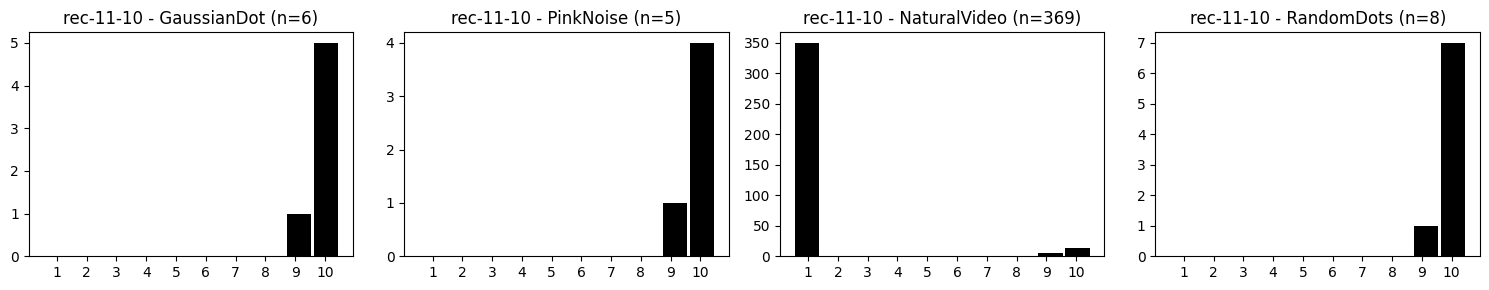

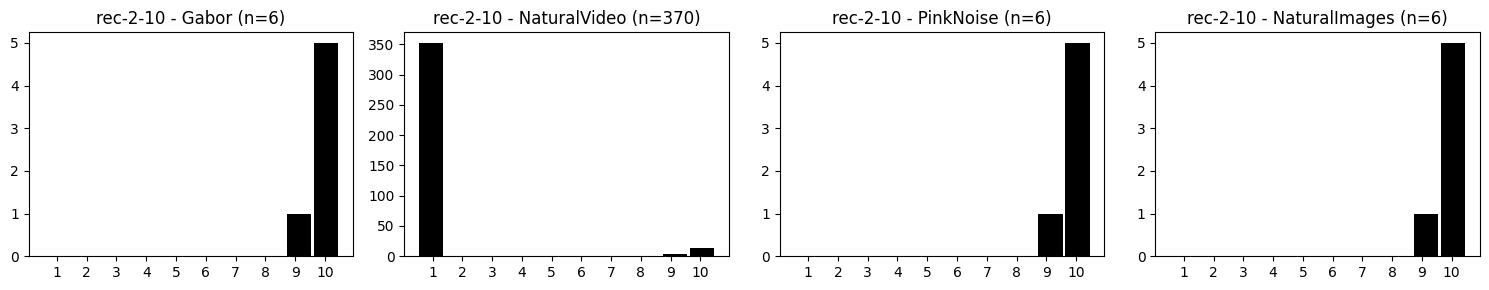

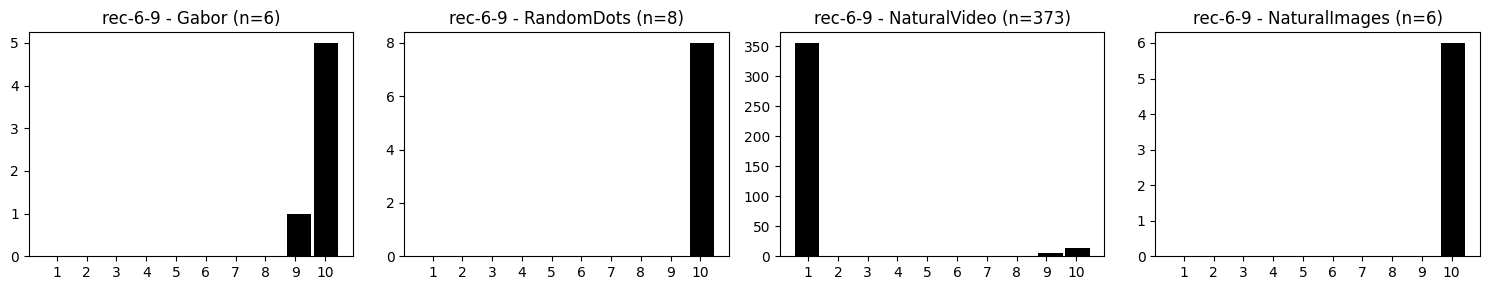

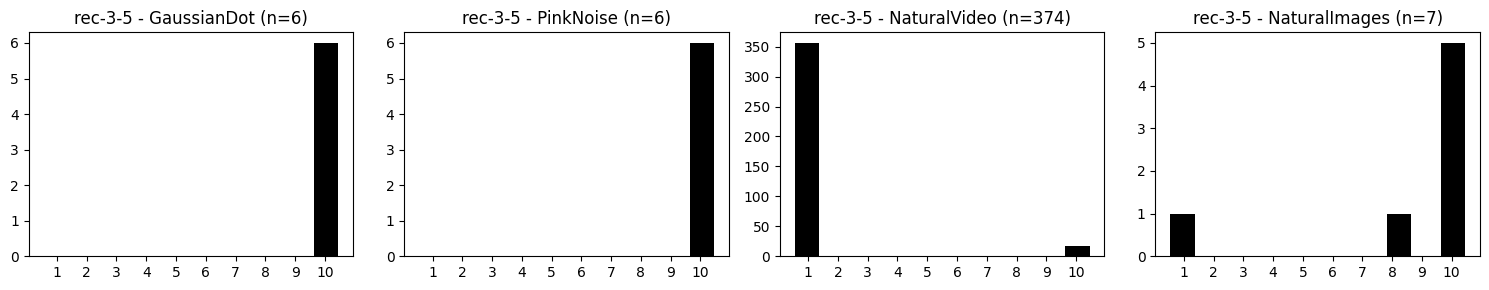

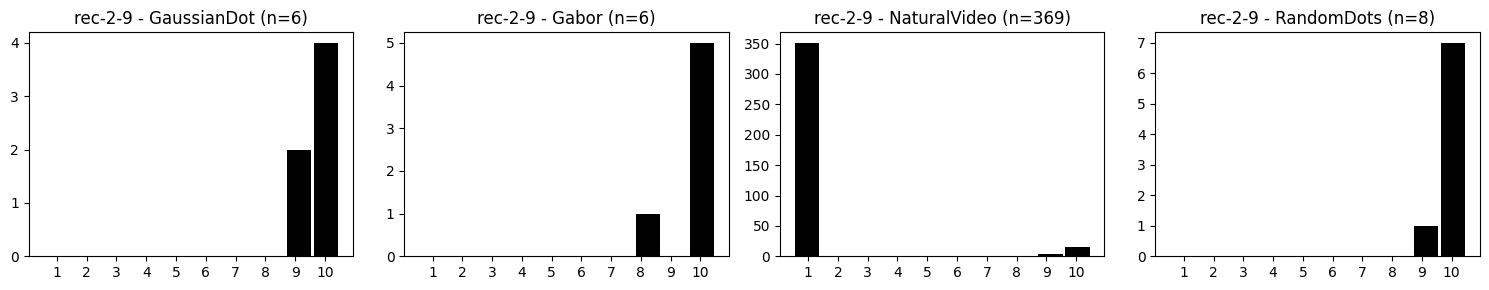

In [30]:
# for each recording and label find the number of replicates of each video
counts = ds.count_videos_across(['recording','label','ID'])

for rec in ds.recording:
    all_trials_df_rec = ds.filter_trials(recording=rec)
    labels = set(all_trials_df_rec['label'].to_list())
        
    fig, ax =plt.subplots(nrows=1, ncols=4, figsize=(15, 3))
    for i, label in enumerate(labels):
        d = counts[(counts['recording']==rec) & (counts['label']==label)]['count'].to_numpy()
        h = ax[i].hist(d, range=(.5, 10.5), bins=11, color='k',rwidth=0.9)
        ax[i].set_xticks(np.arange(1,11))
        ax[i].set_title(f"{mapping[rec]} - {label} (n={len(d)})")

    fig.tight_layout()
    fig.savefig(Path(repo_root, 'figures', f'count-video-duplicates_x-label_{mapping[rec]}.png'))

#### Inspect recording ...3-5... for NaturalImages

In recording ...3-5..., one NaturalImages video appears only once.

Print repetition counts for videos classified as NaturalImages in recording ...3-5....

In [31]:
rec = 'dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce'
label = "NaturalImages"
counts[(counts['recording']==rec) & (counts['label']==label)]

,recording,label,ID,count
90,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v484546,10
103,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v089720,10
111,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v360898,10
113,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v683710,10
122,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v062658,10
184,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,8
1361,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v565001,1


Print a DataFrame with trials for the video ID that appears 8 times.

In [32]:
ds.filter_trials(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', label="NaturalImages", ID='v874315')

,recording,label,ID,trial,trial_type,valid_frames,valid_trial
2344,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,702,live_test_main,305,True
2455,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,719,train,305,True
2648,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,689,train,305,True
2690,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,685,final_test_bonus,306,True
2830,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,693,live_test_bonus,306,True
2832,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,705,live_test_bonus,306,True
2840,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,717,live_test_bonus,305,True
2847,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v874315,681,live_test_bonus,305,True


Print a DataFrame with trials for the video ID that appears only once.

In [33]:
ds.filter_trials(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', label="NaturalImages", ID='v565001')

,recording,label,ID,trial,trial_type,valid_frames,valid_trial
2420,dynamic29513-3-5-Video-8744edeac3b4d1ce16b6809...,NaturalImages,v565001,668,train,403,False


The video that appears once is labeled as an invalid trial; it corresponds to the video with bad segments.

Load the video that appears 8 times and the one that appears once (the invalid trial).

In [34]:
video_i = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='702')
video_j = ds.load_video_by_trial(recording='dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce', trial='668')

For both videos, plot frame-to-frame changes and display sample frames.

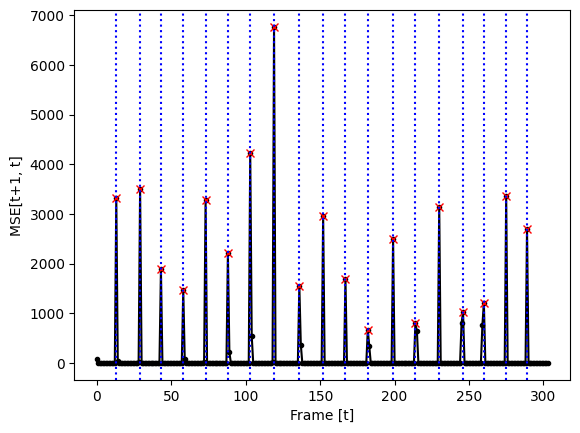

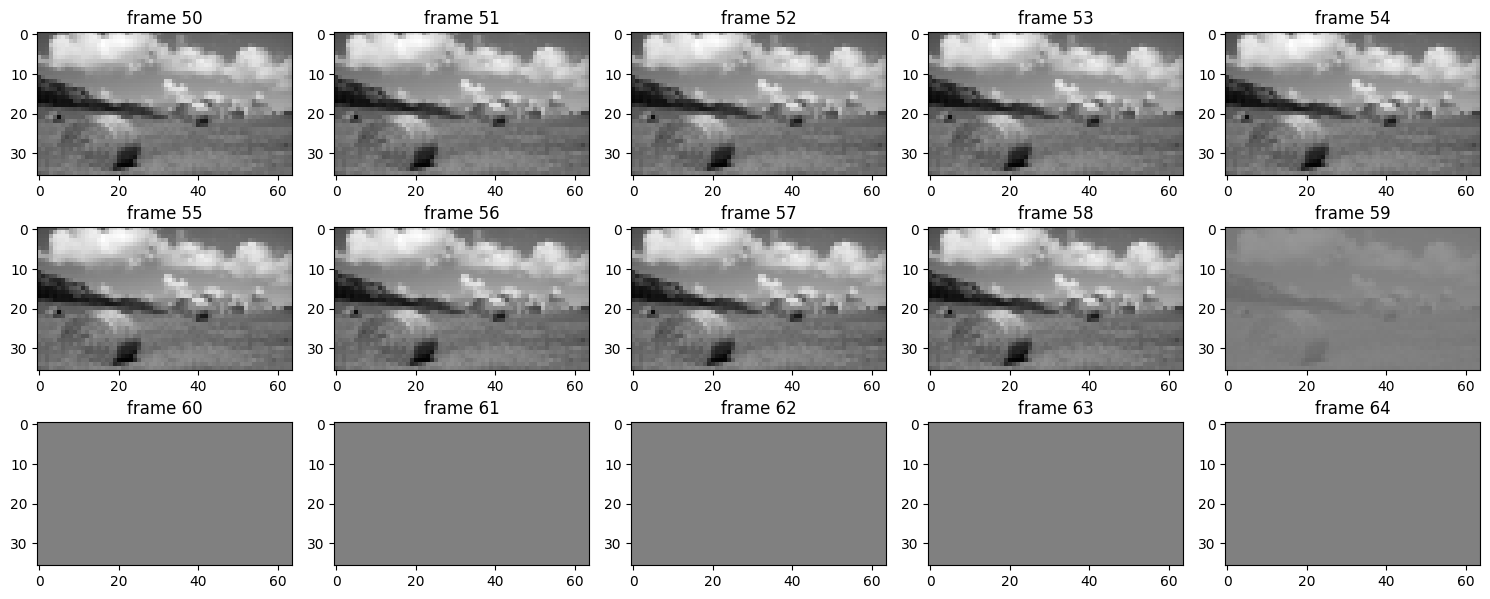

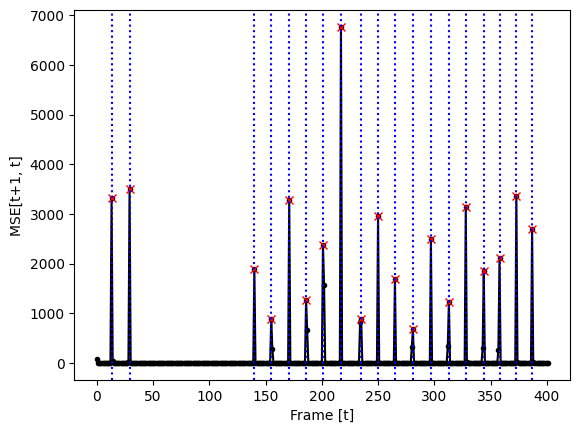

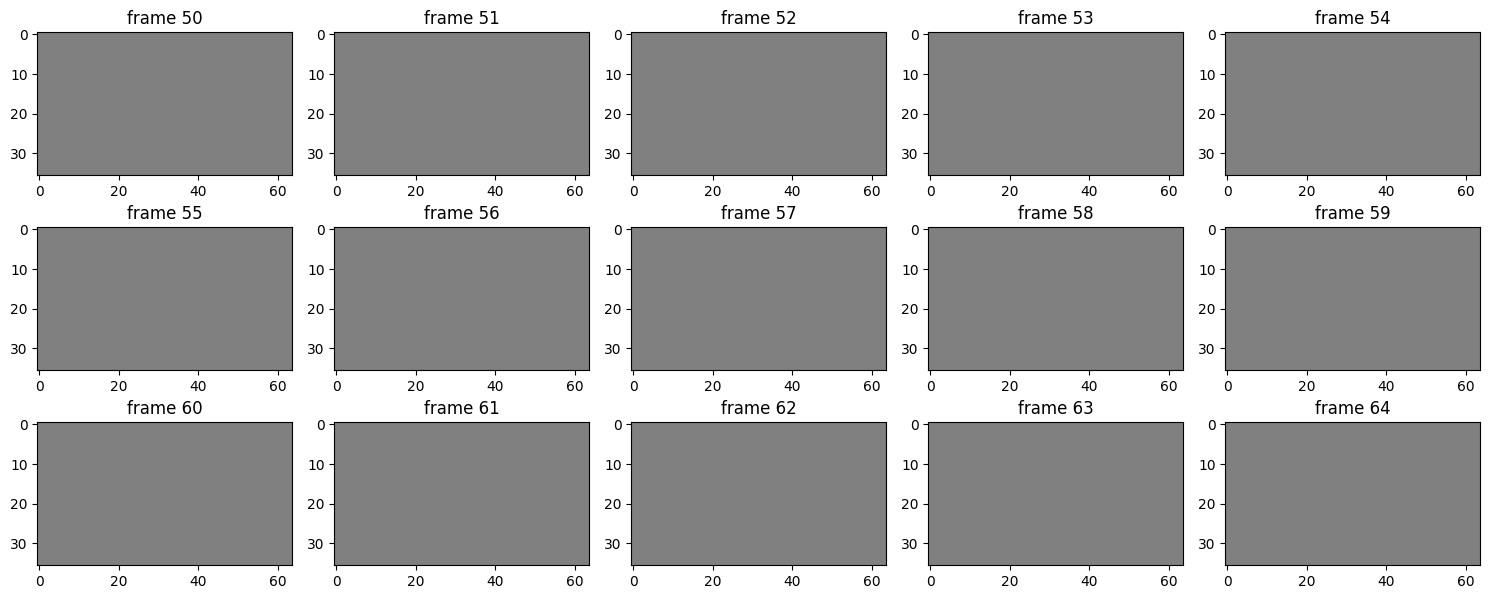

In [35]:
frames = np.arange(50,65)
_ = video_i.plot_changes()
_ = video_i.plot_frames(frames)
_ = video_j.plot_changes()
_ = video_j.plot_frames(frames)

### Check two instances of a repeated video

Print a DataFrame with all trials for one video ID.

In [36]:
ds.filter_trials(recording=all_recording_folders[1], ID="v467193")

,recording,label,ID,trial,trial_type,valid_frames,valid_trial
736,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,NaturalVideo,v467193,180,train,300,True
835,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,NaturalVideo,v467193,461,final_test_bonus,300,True
872,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,NaturalVideo,v467193,141,live_test_bonus,300,True
933,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,NaturalVideo,v467193,191,train,300,True
1123,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,NaturalVideo,v467193,338,live_test_bonus,300,True
1145,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,NaturalVideo,v467193,4,final_test_main,300,True
1194,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,NaturalVideo,v467193,263,final_test_main,300,True
1276,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,NaturalVideo,v467193,526,train,300,True
1390,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,NaturalVideo,v467193,19,final_test_bonus,300,True
1418,dynamic29228-2-10-Video-8744edeac3b4d1ce16b680...,NaturalVideo,v467193,198,final_test_bonus,300,True


Load two trials with the same video ID.

In [37]:
rec = 'dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce'
video_i = ds.load_video_by_trial(recording=rec, trial='526')
video_j = ds.load_video_by_trial(recording=rec, trial='4')

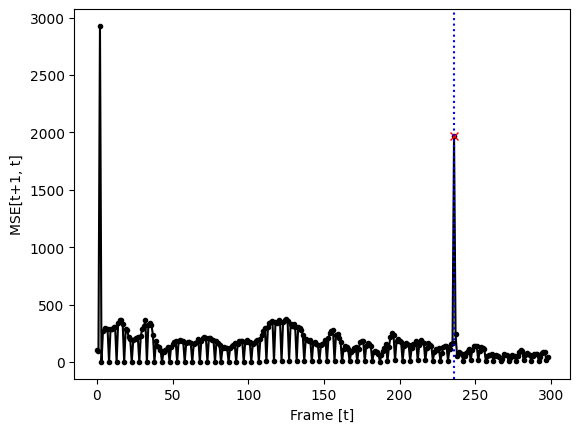

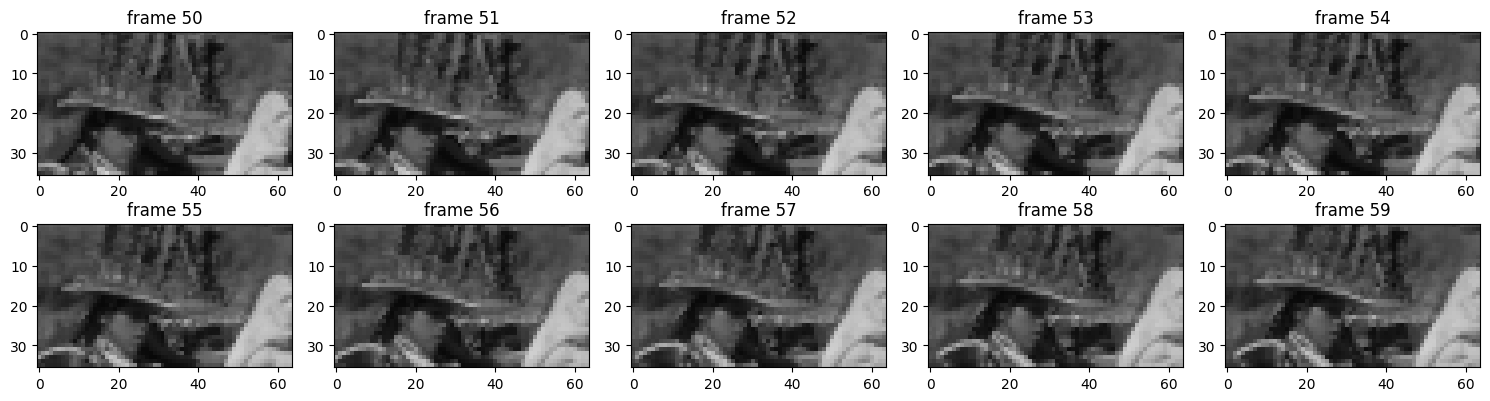

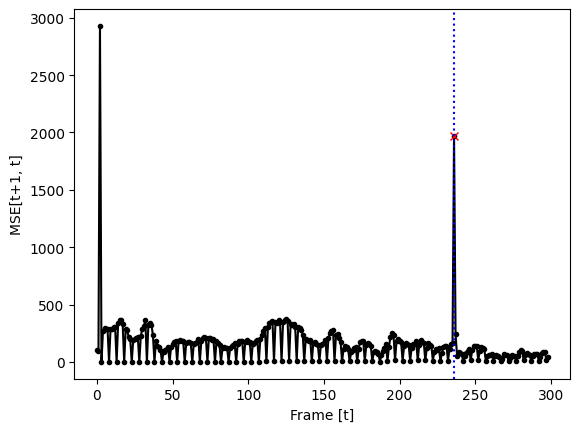

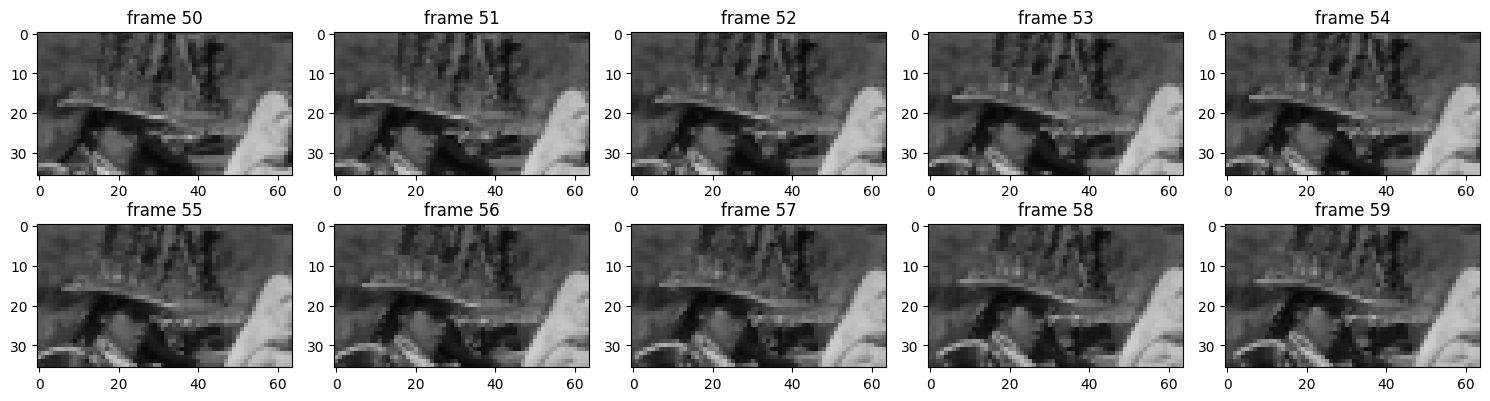

In [38]:
frames = np.arange(50,60)
_ = video_i.plot_changes()
_ = video_i.plot_frames(frames)
_ = video_j.plot_changes()
_ = video_j.plot_frames(frames)

## Video similarity

Check the distribution of dissimilarity values across labels (for one recording).

In [39]:
def plot_dissimilarity_matrix(dissimilarity):
    fig, ax =plt.subplots(nrows=1, ncols=1, figsize=(6, 6))
    vmax = np.max(dissimilarity[np.isnan(dissimilarity)==False].flatten())
    im_diss = ax.imshow(dissimilarity, cmap='Reds_r', vmin=0, vmax=vmax, aspect='equal')
    ax.set_aspect('equal', adjustable='box')
    bcol = fig.colorbar(im_diss, ax=ax)
    bcol.set_label("dissimilarity", rotation=270, labelpad=15)
    ax.set_xlabel("video index")
    ax.set_ylabel("video index")
    return fig, ax

In [40]:
def plot_dissimilarity_hist(dissimilarity,bins=100, range=None):
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 6))
    if range is None:
        range = (0, np.max(dissimilarity[np.isnan(dissimilarity)==False].flatten()))
    h = ax.hist(dissimilarity.flatten(), range=range, bins=bins, color='k', rwidth=1)
    ax.set_xlabel("dissimilarity")
    ax.set_ylabel("video counts")
    return fig, ax

### NaturalVideo

In [41]:
recording_folder = all_recording_folders[1]
thelabel = 'NaturalVideo'
dissimilarity, trials_df = ds.compute_dissimilarity_videos(recording=recording_folder, label=thelabel, check_edges_first=False)

Computing dissimilarity: 100%|██████████| 527/527 [07:50<00:00,  1.12it/s]


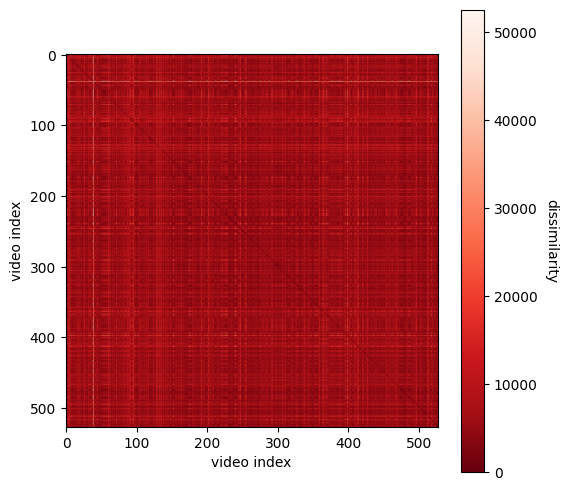

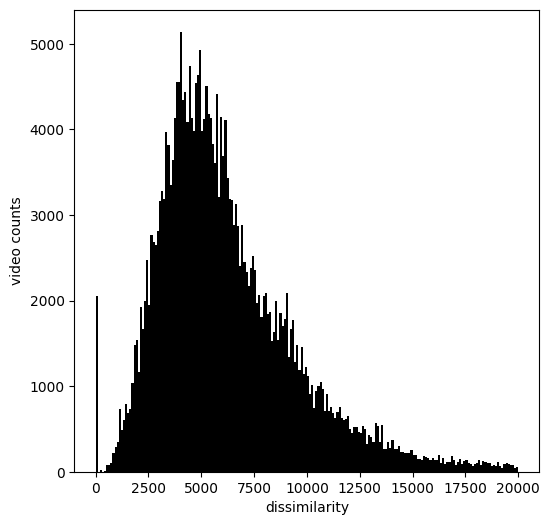

In [42]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_{mapping[recording_folder]}.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=200, range=(0, 20000))
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_{mapping[recording_folder]}.png"), dpi=300)

### Gabor

In [43]:
recording_folder = all_recording_folders[1]
thelabel = 'Gabor'
dissimilarity, trials_df = ds.compute_dissimilarity_videos(recording=recording_folder, label=thelabel, check_edges_first=False)

Computing dissimilarity: 100%|██████████| 59/59 [00:04<00:00, 12.83it/s]


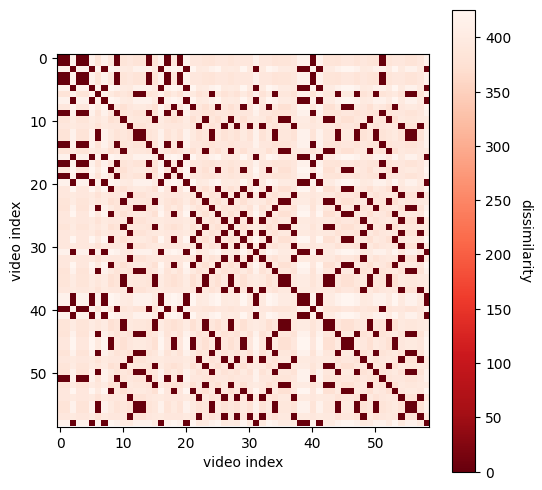

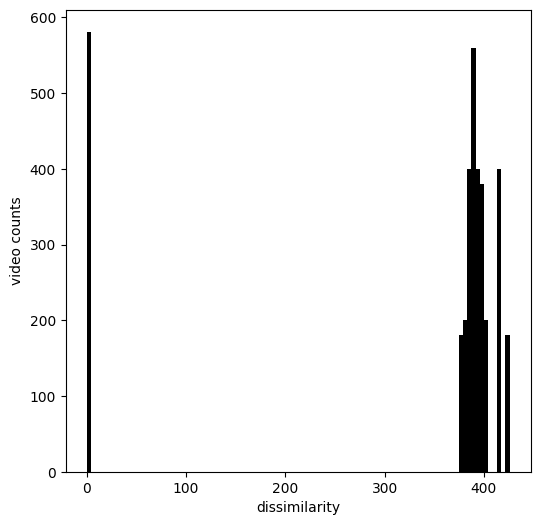

In [44]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_rec-{mapping[recording_folder]}.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=100, range=None)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_rec-{mapping[recording_folder]}.png"), dpi=300)


### NaturalImages

In [45]:
recording_folder = all_recording_folders[1]
thelabel = 'NaturalImages'
dissimilarity, trials_df = ds.compute_dissimilarity_videos(recording=recording_folder, label=thelabel, check_edges_first=False)

Computing dissimilarity: 100%|██████████| 59/59 [00:05<00:00, 10.54it/s]


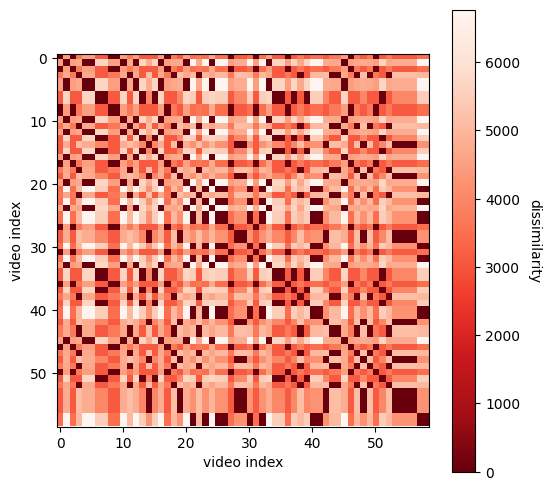

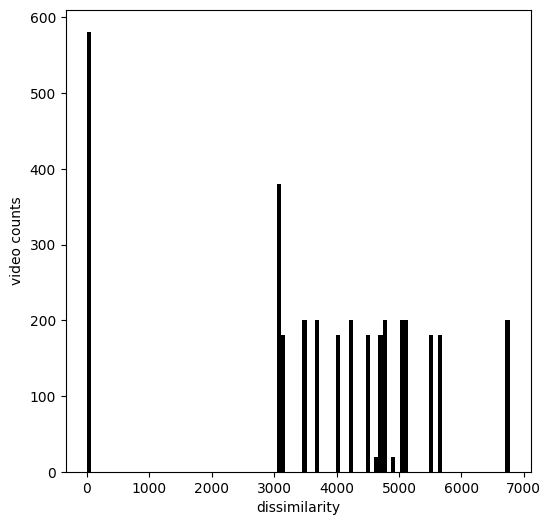

In [46]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_{mapping[recording_folder]}.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=100, range=None)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_{mapping[recording_folder]}.png"), dpi=300)


### PinkNoise

In [47]:
recording_folder = all_recording_folders[1]
thelabel = 'PinkNoise'
dissimilarity, trials_df = ds.compute_dissimilarity_videos(recording=recording_folder, label=thelabel, check_edges_first=False)

Computing dissimilarity: 100%|██████████| 59/59 [00:04<00:00, 12.41it/s]


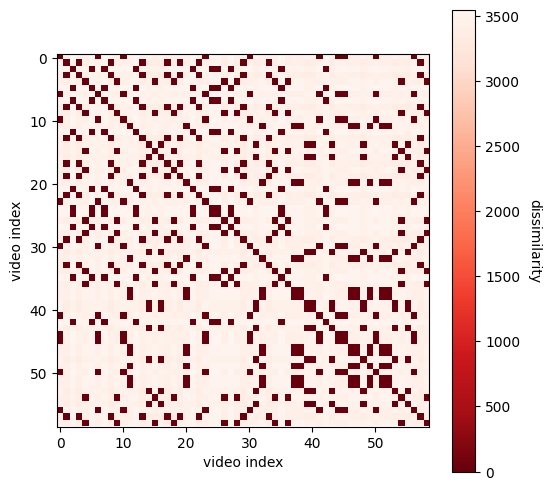

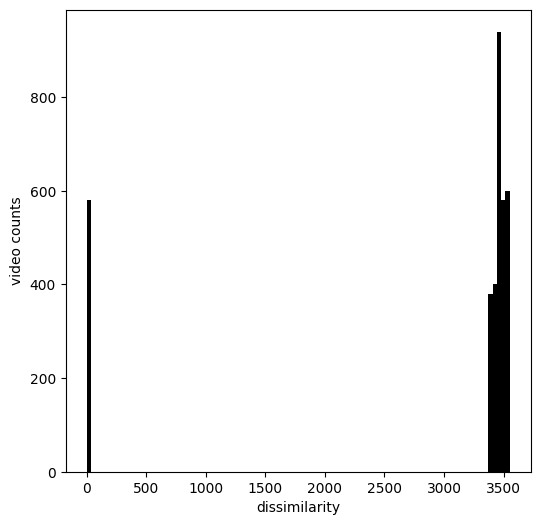

In [48]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_{mapping[recording_folder][3:-3]}.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=100, range=None)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_{mapping[recording_folder][3:-3]}.png"), dpi=300)


### RandomDots

In [49]:
recording_folder = all_recording_folders[0]
thelabel = 'RandomDots'
dissimilarity, trials_df = ds.compute_dissimilarity_videos(recording=recording_folder, label=thelabel, check_edges_first=False)

Computing dissimilarity: 100%|██████████| 79/79 [00:06<00:00, 11.43it/s]


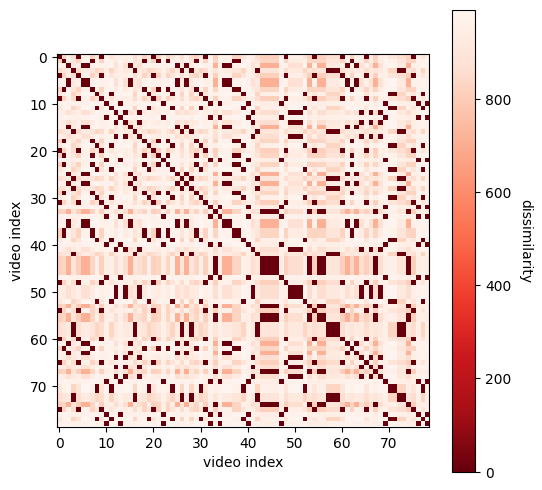

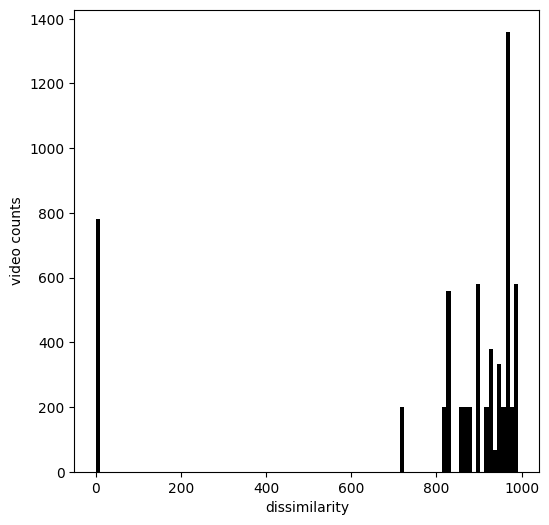

In [50]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_{mapping[recording_folder][3:-3]}.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=100, range=None)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_{mapping[recording_folder][3:-3]}.png"), dpi=300)


### GaussianDot

In [51]:
recording_folder = all_recording_folders[0]
thelabel = 'GaussianDot'
dissimilarity, trials_df = ds.compute_dissimilarity_videos(recording=recording_folder, label=thelabel, check_edges_first=False)

Computing dissimilarity: 100%|██████████| 59/59 [00:06<00:00,  9.22it/s]


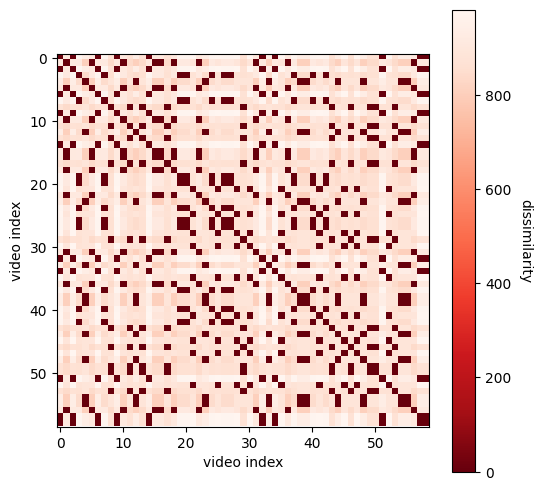

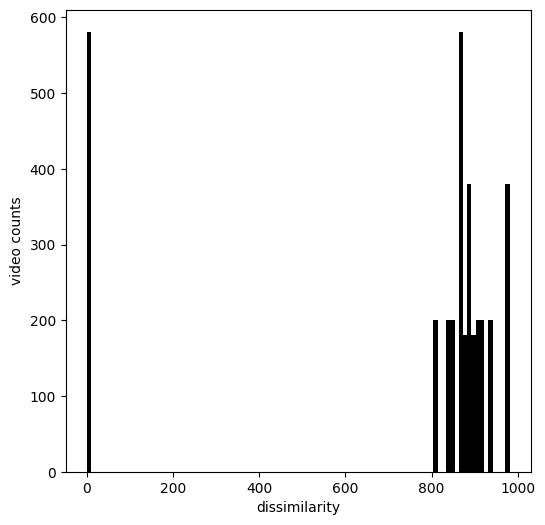

In [52]:
# plot dissimilarity matrix
fig, ax = plot_dissimilarity_matrix(dissimilarity)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-matrix_{thelabel}_{mapping[recording_folder][3:-3]}.png"), dpi=300)

# plot histogrma with the distribution
fig, ax = plot_dissimilarity_hist(dissimilarity,bins=100, range=None)
fig.savefig(Path(repo_root, 'figures', f"dissimilarity-hist_{thelabel}_{mapping[recording_folder][3:-3]}.png"), dpi=300)
